In [1]:
%cd ..

C:\Users\malte\EvoMUSART23-repro-code


In [2]:
import librosa
from glob import glob
import matplotlib.pyplot as plt
import numpy as np

from evoaudio.base_algorithms import approximate_piece
from evoaudio.base_sample import BaseSample
from evoaudio.individual import BaseIndividual
from evoaudio.mutations import Mutator
from evoaudio.population import Population
from evoaudio.sample_library import SampleLibrary
from evoaudio.population_logging import PopulationLogger
from evoaudio.jaccard import calc_jaccard_for_chord_approximation
from parsing.arff_parsing import parse_arff

In [3]:
sample_lib = SampleLibrary()

Loading samples:   0%|          | 0/6826 [00:00<?, ?it/s]

In [4]:
N_INDIVIDUALS = 100

MAX_STEPS = 10000
POPSIZE = 10
N_OFFSPRING = 1

In [5]:
class GroundTruthIndividual(BaseIndividual):
    def __init__(self, phi: float = 0.1, hold_delay: int = 5512):
        super().__init__(phi)
        self.hold_delay = 5512
        self.holds = []

    def __str__(self):
        s = f"Fitness: {self.fitness} | " + ", ".join(str(x) for x in self.samples) + ", ".join(str(hold) for hold in self.holds)
        return s

    def add_sample(self, sample:BaseSample, hold:bool):
        self.samples.append(sample)
        self.holds.append(hold)

    def remove_sample(self, remove_idx):
        self.samples.pop(remove_idx)
        self.holds.pop(remove_idx)

    def to_mixdown(self) -> np.ndarray:
        """Creates a mix of the samples contained in the collection.

        Returns
        -------
        np.ndarray
            Mix of the samples.
        """
        ys_holding = []
        for i in range(len(self.samples)):
            if self.holds[i]:
                ys_holding.append(self.samples[i].y[self.hold_delay:])
            else:
                ys_holding.append(self.samples[i].y)
        max_length = np.max([len(y) for y in ys_holding])
        ys_equal_length = [np.pad(y, (0, max_length - len(y))) for y in ys_holding]
        return np.sum(ys_equal_length, axis=0)
    
    @classmethod
    def create_random_individual(cls, sample_lib:SampleLibrary, max_samples:int=5, sample_num_p:list[float]=[0.1, 0.3, 0.3, 0.2, 0.1], phi:float=0.1):
        individual = cls(phi=phi)
        for _ in range(np.random.choice(list(range(max_samples)), p=sample_num_p) + 1):
            individual.add_sample(sample_lib.get_random_sample_uniform(), hold=np.random.choice(a=[False, True], p=[0.8, 0.2]))
        return individual

true_individuals = [GroundTruthIndividual.create_random_individual(sample_lib=sample_lib) for _ in range(N_INDIVIDUALS)]


In [6]:
class Logger():
    def __init__(self) -> None:
        self.logged_errors = []
        self.logged_fitnesses = []
        self.logged_diversity = []
    def log_errors(self, pop, annotation):
        errors = calc_jaccard_for_chord_approximation(pop=pop, annotation=annotation)
        self.logged_errors.append(errors)
    def log_fitness(self, pop):
        self.logged_fitnesses.append(pop.archive[0].fitness)
    def log_diversity(self, pop):
        unique = set(pop.individuals)  
        self.logged_diversity.append(len(unique))

In [7]:
parent_strategies = ["random", "tournament"]
survivor_strategies = ["worst", "tournament", "tournament_no_elite"]

In [8]:
all_results = {}

for parent_strat in parent_strategies:
    for survivor_strat in survivor_strategies:
        key = f"{parent_strat}_{survivor_strat}"
        all_results[key] = {
            "results": [],
            "error_logs": [],
            "fitness_logs": [],
            "diversity_logs": []
        }

        for true_ind in true_individuals:
            print(f"Running: {key} | Target: {str(true_ind)}")
            logger = Logger()
            mutator = Mutator(sample_library=sample_lib, choose_mutation_p=[0.4, 0.4, 0.1, 0.1])
            
            def callback(pop: Population, step: int):
                annotation = [(sample.instrument, sample.pitch) for sample in true_ind.samples]
                logger.log_errors(pop=pop, annotation=annotation)
                logger.log_fitness(pop=pop)
                logger.log_diversity(pop=pop)

            result = approximate_piece(
                target_y=true_ind.to_mixdown(), 
                max_steps=MAX_STEPS, 
                sample_lib=sample_lib, 
                popsize=POPSIZE, 
                n_offspring=N_OFFSPRING, 
                onset_frac=1.0, zeta=0.9954,
                early_stopping_fitness=0.0001,
                onsets=[0], verbose=False, callback=callback,
                parent_selection=parent_strat,
                survivor_selection=survivor_strat
            )

            all_results[key]["results"].append(result)
            all_results[key]["error_logs"].append(logger.logged_errors)
            all_results[key]["fitness_logs"].append(logger.logged_fitnesses)
            all_results[key]["diversity_logs"].append(logger.logged_diversity)

Running: random_worst | Target: Fitness: inf | (Pinkillo, pinkillo, f6), (TampuraPAndBrothers, tampura, fis2)False, True
Running: random_worst | Target: Fitness: inf | (Contrabassoon, Contrabassoon_Essential, e3), (Drums, AR60s_LateKit, FXCymbal1), (Bass, Basses_Essential, d1)False, True, False
Running: random_worst | Target: Fitness: inf | (Ukulele, ukulele, gis5), (Bass, Basses_SessionStringsPro, e2), (Piano, The_Grandeur, a2), (Saxophone, Saxophone_Essential, f3), (Clarinet, Clarinets_Essential, e3)False, True, True, True, True
Running: random_worst | Target: Fitness: inf | (Drums, AR50s_AutumnKit, Hihat_Closed_Pedal), (Shakuhachi, shakuhachi, a3)False, False
Running: random_worst | Target: Fitness: inf | (Tanbur, tanbur, ais1), (Contrabassoon, Contrabassoon_Essential, gis2)True, False
Running: random_worst | Target: Fitness: inf | (Contrabassoon, Contrabassoon_Essential, ais0), (Trombone, BassTrombone_SessionHornsPro, gis3)False, False
Running: random_worst | Target: Fitness: inf |

Running: random_worst | Target: Fitness: inf | (Bandura, bandura, a3)True
Running: random_worst | Target: Fitness: inf | (Dilruba, dilruba, cis4), (Pinkillo, pinkillo, cis5), (Banjolin, banjolin, b3)False, False, False
Running: random_worst | Target: Fitness: inf | (PivanaFlute, pivana_flute, b5), (Cello, Cellos_SessionStringsPro, d4), (Pinkillo, pinkillo, a6), (Bandura, bandura, f6)False, False, False, True
Running: random_worst | Target: Fitness: inf | (CumbusOpenStrings, cumbus, a3), (CumbusOpenStrings, cumbus, g4), (TurkeySaz, turkey_saz, f4), (BouzoukiSakis, boizouki, g3)False, False, True, False
Running: random_worst | Target: Fitness: inf | (Banjolin, banjolin, gis5), (Flute, tr331FLVIM, cis5), (Viola, tr161VLNVM, cis4)False, False, True
Running: random_worst | Target: Fitness: inf | (BouzoukiSakis, boizouki, ais4), (Banjolin, banjolin, b3)False, False
Running: random_worst | Target: Fitness: inf | (Violin, Violins1_Essential, b5)False
Running: random_worst | Target: Fitness: in

Running: random_tournament | Target: Fitness: inf | (JinghuOperaviolin, jinghu_opera_violin, d6), (Saxophone, BaritoneSax_SessionHornsPro, gis4), (Domra, domra, ais3), (PivanaFlute, pivana_flute, e6), (ElectricBass, Scarbee_JayBass_Slap_Neck, e4)False, False, False, False, False
Running: random_tournament | Target: Fitness: inf | (Bandura, bandura, dis5), (KanteleLowWideRange, kantele, g4), (Pinkillo, pinkillo, dis5), (Organ, Errol_G, dis5)True, False, False, False
Running: random_tournament | Target: Fitness: inf | (DungDkarTrumpet, dung_dkar_trumpet, e3), (Banjolin, banjolin, e4)True, False
Running: random_tournament | Target: Fitness: inf | (BouzoukiSakis, boizouki, d3), (Cello, tr172VCNVM, f4)True, False
Running: random_tournament | Target: Fitness: inf | (Bassoon, Bassoons_Essential, b2), (Bandura, bandura, c6), (KanteleLowWideRange, kantele, dis5)False, False, False
Running: random_tournament | Target: Fitness: inf | (Pinkillo, pinkillo, gis6), (JinghuOperaviolin, jinghu_opera_vi

Running: random_tournament | Target: Fitness: inf | (Violin, Violins1_Essential, b5)False
Running: random_tournament | Target: Fitness: inf | (AcousticGuitar, tr112AGAFM, b4), (TurkeySaz, turkey_saz, g2), (Pinkillo, pinkillo, gis6)True, False, False
Running: random_tournament | Target: Fitness: inf | (Drums, AR80s_ChromeKit, Kick1), (EgyptianFiddle, egyptian_fiddle, e4)True, False
Running: random_tournament | Target: Fitness: inf | (CeylonGuitar, ceylon_guitar, gis3), (Trombone, TenorTrombone_SessionHornsPro, e2), (Bandura, bandura, c3)False, False, False
Running: random_tournament | Target: Fitness: inf | (PivanaFlute, pivana_flute, g5)False
Running: random_tournament | Target: Fitness: inf | (Violin, Violins_SessionStringsPro, ais3), (JinghuOperaviolin, jinghu_opera_violin, a4), (Bawu, bawu, dis4)True, False, False
Running: random_tournament | Target: Fitness: inf | (Panflute, panflute, f3), (Domra, domra, cis4), (Panflute, panflute, a3), (Pinkillo, pinkillo, fis6)True, False, False,

Running: random_tournament_no_elite | Target: Fitness: inf | (BouzoukiSakis, boizouki, d3), (Cello, tr172VCNVM, f4)True, False
Running: random_tournament_no_elite | Target: Fitness: inf | (Bassoon, Bassoons_Essential, b2), (Bandura, bandura, c6), (KanteleLowWideRange, kantele, dis5)False, False, False
Running: random_tournament_no_elite | Target: Fitness: inf | (Pinkillo, pinkillo, gis6), (JinghuOperaviolin, jinghu_opera_violin, g5), (Oboe, Oboes_Essential, d5), (Flute, Flute_Essential, b5)False, True, False, True
Running: random_tournament_no_elite | Target: Fitness: inf | (Erhu, erhu_key, b5), (Ukulele, ukulele, f5), (Clarinet, Clarinets_Essential, cis3)False, False, False
Running: random_tournament_no_elite | Target: Fitness: inf | (Drums, AR70s_TightKit, Crash1_Bell), (Fujara, fujara, fis6)True, False
Running: random_tournament_no_elite | Target: Fitness: inf | (AcousticGuitar, tr113AGAFM, a3), (Pinkillo, pinkillo, ais6), (Oboe, Oboe_Essential, gis4)True, False, False
Running: rand

...

Running: tournament_worst | Target: Fitness: inf | (PivanaFlute, pivana_flute, g5)False
Running: tournament_worst | Target: Fitness: inf | (Violin, Violins_SessionStringsPro, ais3), (JinghuOperaviolin, jinghu_opera_violin, a4), (Bawu, bawu, dis4)True, False, False
Running: tournament_worst | Target: Fitness: inf | (Panflute, panflute, f3), (Domra, domra, cis4), (Panflute, panflute, a3), (Pinkillo, pinkillo, fis6)True, False, False, False
Running: tournament_worst | Target: Fitness: inf | (Piano, The_Maverick, c5), (Balalaika, balalaika, cis3), (Panflute, panflute, dis5)False, False, False
Running: tournament_worst | Target: Fitness: inf | (AcousticGuitar, tr111AGRFM, f4), (CeylonGuitar, ceylon_guitar, f2)False, False
Running: tournament_worst | Target: Fitness: inf | (CeylonGuitar, ceylon_guitar, dis2), (Trumpet, trCTpt, ais4)False, False
Running: tournament_worst | Target: Fitness: inf | (Flute, tr332FLNOM, d4), (Horn, Flugelhorn_SessionHornsPro, dis5)True, False
Running: tournament_w

Running: tournament_tournament | Target: Fitness: inf | (Drums, AR70s_TightKit, Crash1_Bell), (Fujara, fujara, fis6)True, False
Running: tournament_tournament | Target: Fitness: inf | (AcousticGuitar, tr113AGAFM, a3), (Pinkillo, pinkillo, ais6), (Oboe, Oboe_Essential, gis4)True, False, False
Running: tournament_tournament | Target: Fitness: inf | (Flute, tr331FLNOM, fis4), (Erhu, erhu_key, ais4), (Balalaika, balalaika, d4), (ElectricBass, Scarbee_Rickenbacker_Bass_PalmMuted, b1)True, False, False, False
Running: tournament_tournament | Target: Fitness: inf | (Clarinet, Clarinet_Essential, cis4), (Drums, AR60s_EarlyKit, Snare_RimOnly)False, False
Running: tournament_tournament | Target: Fitness: inf | (BanjoFramus, banjo_framus, g5), (Tuba, Tuba_Essential, b2), (CeylonGuitar, ceylon_guitar, ais3), (Pinkillo, pinkillo, fis5)False, False, False, False
Running: tournament_tournament | Target: Fitness: inf | (ElectricPiano, Scarbee_Clavinet_Full_DI, e2), (Saxophone, Saxophone_Essential, ais

Running: tournament_tournament | Target: Fitness: inf | (Piano, The_Maverick, c5), (Balalaika, balalaika, cis3), (Panflute, panflute, dis5)False, False, False
Running: tournament_tournament | Target: Fitness: inf | (AcousticGuitar, tr111AGRFM, f4), (CeylonGuitar, ceylon_guitar, f2)False, False
Running: tournament_tournament | Target: Fitness: inf | (CeylonGuitar, ceylon_guitar, dis2), (Trumpet, trCTpt, ais4)False, False
Running: tournament_tournament | Target: Fitness: inf | (Flute, tr332FLNOM, d4), (Horn, Flugelhorn_SessionHornsPro, dis5)True, False
Running: tournament_tournament | Target: Fitness: inf | (TampuraPAndBrothers, tampura, d3), (ElectricBass, Scarbee_JayBass_Neck, cis4), (TurkeySaz, turkey_saz, cis3)False, False, False
Running: tournament_tournament | Target: Fitness: inf | (Organ, The_Worm, d4), (DungDkarTrumpet, dung_dkar_trumpet, a4), (Violin, Violins_SessionStringsPro, f6), (ElectricGuitar, tr131EGVPM, a3), (Trumpet, tr211TRNOM, e3)True, False, False, False, False
Runn

Running: tournament_tournament_no_elite | Target: Fitness: inf | (AcousticGuitar, tr113AGAFM, a3), (Pinkillo, pinkillo, ais6), (Oboe, Oboe_Essential, gis4)True, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Flute, tr331FLNOM, fis4), (Erhu, erhu_key, ais4), (Balalaika, balalaika, d4), (ElectricBass, Scarbee_Rickenbacker_Bass_PalmMuted, b1)True, False, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Clarinet, Clarinet_Essential, cis4), (Drums, AR60s_EarlyKit, Snare_RimOnly)False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (BanjoFramus, banjo_framus, g5), (Tuba, Tuba_Essential, b2), (CeylonGuitar, ceylon_guitar, ais3), (Pinkillo, pinkillo, fis5)False, False, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (ElectricPiano, Scarbee_Clavinet_Full_DI, e2), (Saxophone, Saxophone_Essential, ais3)False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Ba

Running: tournament_tournament_no_elite | Target: Fitness: inf | (Violin, Violins_SessionStringsPro, ais3), (JinghuOperaviolin, jinghu_opera_violin, a4), (Bawu, bawu, dis4)True, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Panflute, panflute, f3), (Domra, domra, cis4), (Panflute, panflute, a3), (Pinkillo, pinkillo, fis6)True, False, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Piano, The_Maverick, c5), (Balalaika, balalaika, cis3), (Panflute, panflute, dis5)False, False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (AcousticGuitar, tr111AGRFM, f4), (CeylonGuitar, ceylon_guitar, f2)False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (CeylonGuitar, ceylon_guitar, dis2), (Trumpet, trCTpt, ais4)False, False
Running: tournament_tournament_no_elite | Target: Fitness: inf | (Flute, tr332FLNOM, d4), (Horn, Flugelhorn_SessionHornsPro, dis5)True, False
Running: tournament_tourn

Plotting: random_worst


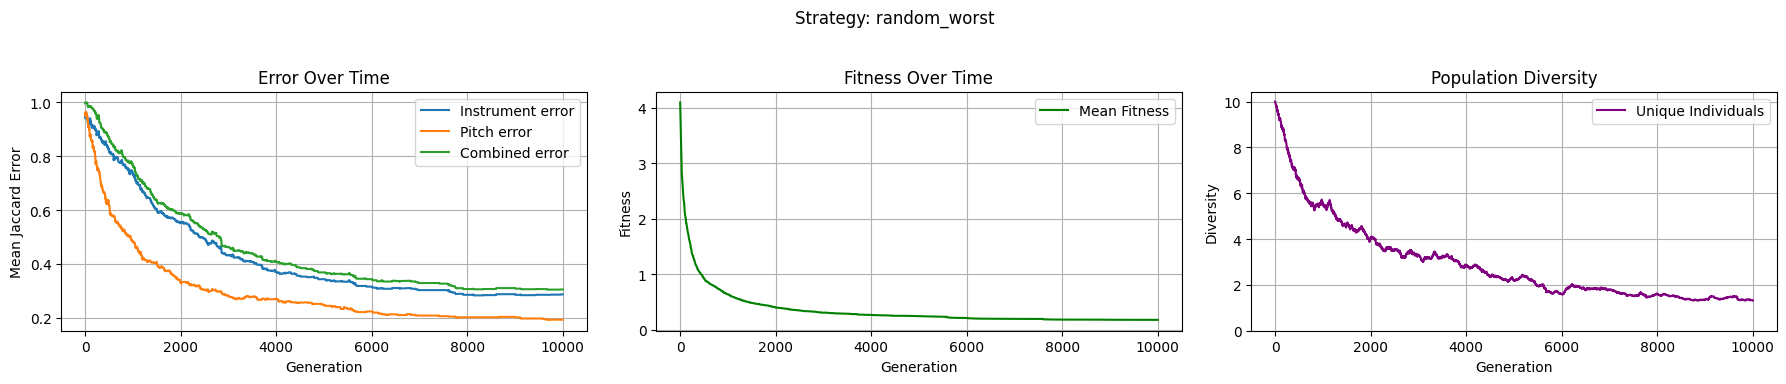

Plotting: random_tournament


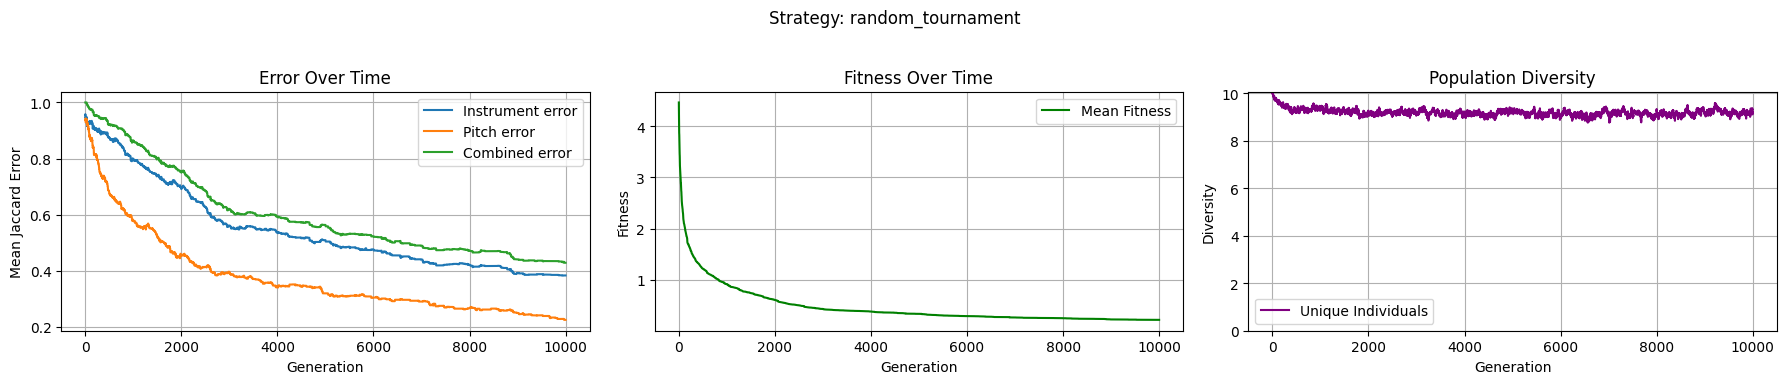

Plotting: random_tournament_no_elite


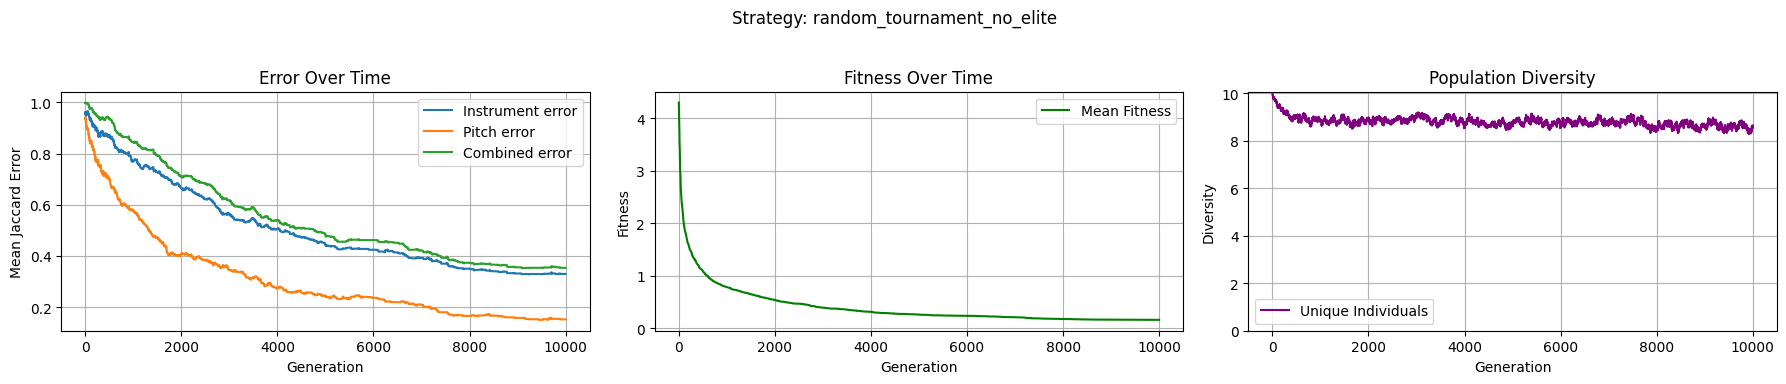

Plotting: tournament_worst


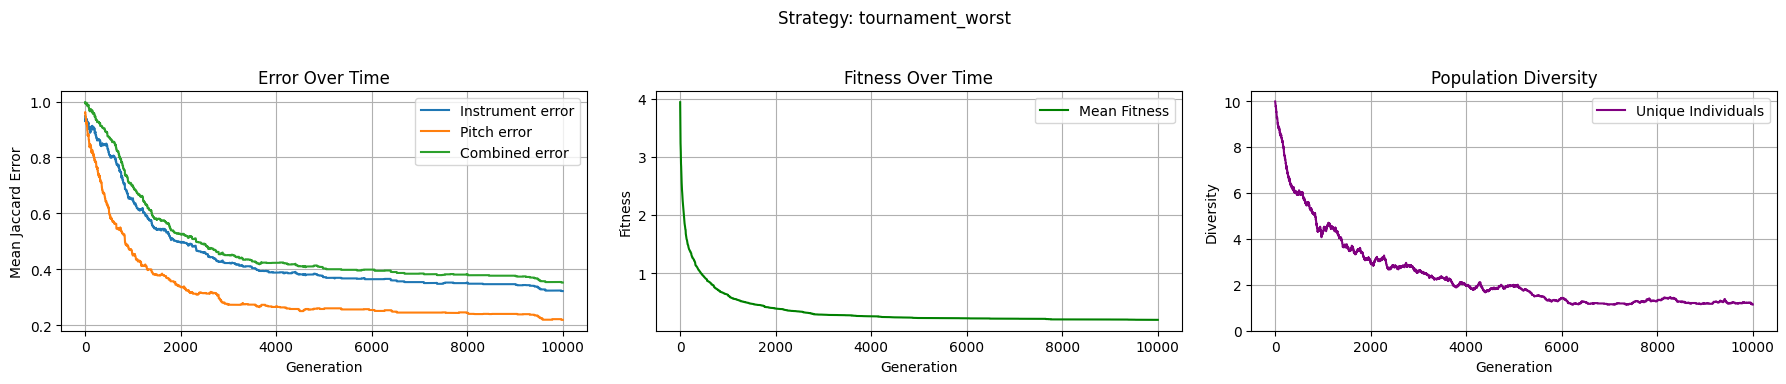

Plotting: tournament_tournament


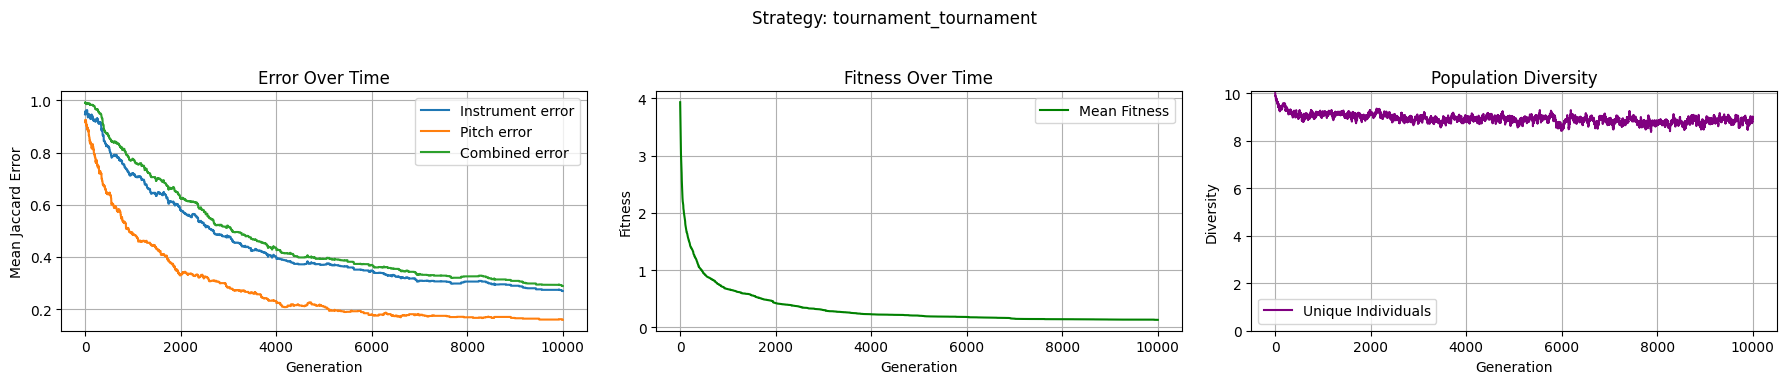

Plotting: tournament_tournament_no_elite


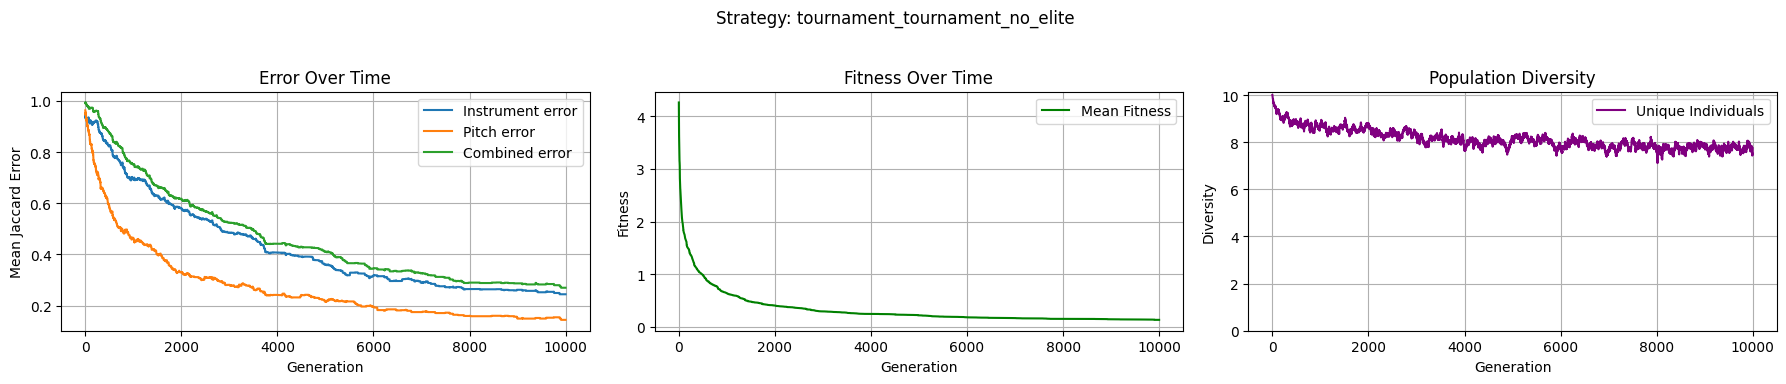

In [9]:
import numpy as np
import matplotlib.pyplot as plt

for key, data in all_results.items():
    print(f"Plotting: {key}")
    
    # Initialize logs
    j_i_logs, j_p_logs, j_ip_logs = [], [], []

    # Extract error logs and pad
    for log in data["error_logs"]:
        j_i, j_p, j_ip = [], [], []
        for tup in log:
            j_i.append(tup[0])
            j_p.append(tup[1])
            j_ip.append(tup[2])
        # Pad with np.nan (ignored in nanmean)
        while len(j_i) < MAX_STEPS:
            j_i.append(0)
            j_p.append(0)
            j_ip.append(0)
        j_i_logs.append(j_i)
        j_p_logs.append(j_p)
        j_ip_logs.append(j_ip)
    
    j_i_mean = np.nanmean(np.array(j_i_logs), axis=0)
    j_p_mean = np.nanmean(np.array(j_p_logs), axis=0)
    j_ip_mean = np.nanmean(np.array(j_ip_logs), axis=0)

    # Fitness
    fitness_padded = []
    for log in data["fitness_logs"]:
        fit = log + [0] * (MAX_STEPS - len(log))
        fitness_padded.append(fit)
    fitness_means = np.nanmean(np.array(fitness_padded), axis=0)

    # Diversity
    diversity_array = np.array([
        log + [np.nan] * (MAX_STEPS - len(log)) 
        for log in data["diversity_logs"]
    ])
    diversity_mean = np.nanmean(diversity_array, axis=0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Strategy: {key}")

    # Error plot
    axes[0].plot(j_i_mean, label="Instrument error")
    axes[0].plot(j_p_mean, label="Pitch error")
    axes[0].plot(j_ip_mean, label="Combined error")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Mean Jaccard Error")
    axes[0].set_title("Error Over Time")
    axes[0].legend()
    axes[0].grid(True)

    # Fitness plot
    axes[1].plot(fitness_means, label="Mean Fitness", color="green")
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Fitness")
    axes[1].set_title("Fitness Over Time")
    axes[1].legend()
    axes[1].grid(True)

    # Diversity plot
    axes[2].plot(diversity_mean, label="Unique Individuals", color="purple")
    axes[2].set_xlabel("Generation")
    axes[2].set_ylabel("Diversity")
    axes[2].set_title("Population Diversity")
    axes[2].legend()
    axes[2].grid(True)
    axes[2].set_ylim(bottom=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare containers
mean_j_i_per_strategy = {}
mean_j_p_per_strategy = {}
mean_j_ip_per_strategy = {}
mean_fitness_per_strategy = {}
mean_diversity_per_strategy = {}

for key, data in all_results.items():
    # --- Error logs ---
    j_i_logs, j_p_logs, j_ip_logs = [], [], []
    for log in data["error_logs"]:
        j_i, j_p, j_ip = [], [], []
        for tup in log:
            j_i.append(tup[0])
            j_p.append(tup[1])
            j_ip.append(tup[2])
        j_i += [0] * (MAX_STEPS - len(j_i))
        j_p += [0] * (MAX_STEPS - len(j_p))
        j_ip += [0] * (MAX_STEPS - len(j_ip))
        j_i_logs.append(j_i)
        j_p_logs.append(j_p)
        j_ip_logs.append(j_ip)
    
    mean_j_i_per_strategy[key] = np.nanmean(j_i_logs, axis=0)
    mean_j_p_per_strategy[key] = np.nanmean(j_p_logs, axis=0)
    mean_j_ip_per_strategy[key] = np.nanmean(j_ip_logs, axis=0)

    # --- Fitness logs ---
    fitness_logs = [
        log + [0] * (MAX_STEPS - len(log))
        for log in data["fitness_logs"]
    ]
    mean_fitness_per_strategy[key] = np.nanmean(fitness_logs, axis=0)

    # --- Diversity logs ---
    diversity_logs = [
        log + [np.nan] * (MAX_STEPS - len(log))
        for log in data["diversity_logs"]
    ]
    mean_diversity_per_strategy[key] = np.nanmean(diversity_logs, axis=0)



In [11]:
import os
filename_suffix = f"nind{N_INDIVIDUALS}_steps{MAX_STEPS}_pop{POPSIZE}_offspring{N_OFFSPRING}"

def plot_metric(metric_dict, title, ylabel, legend_loc='best', save=False):
    plt.figure(figsize=(10, 5))
    for key, values in metric_dict.items():
        label = f"{key}"
        plt.plot(values, label=label)
    plt.title(title)
    plt.xlabel("Generation")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend(loc=legend_loc)
    plt.tight_layout()
    plt.ylim(bottom=0)
    if(save):
        filename = f"{title}_{filename_suffix}.png"
        filepath = os.path.join("experiments/strategies", filename)
        plt.savefig(filepath)
    plt.show()

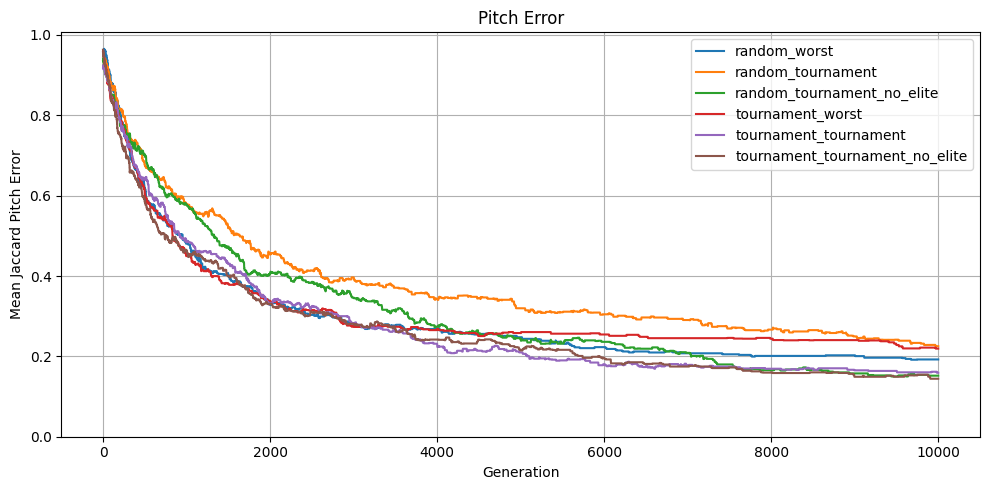

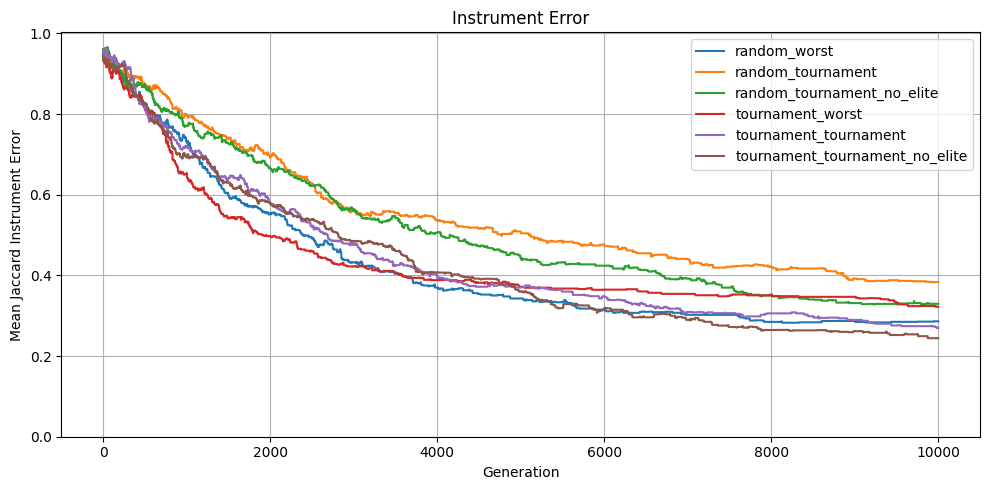

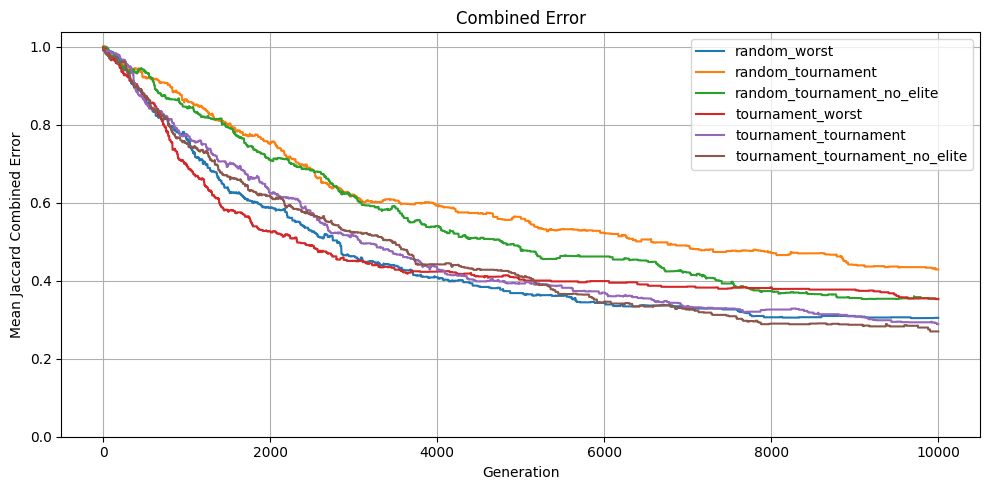

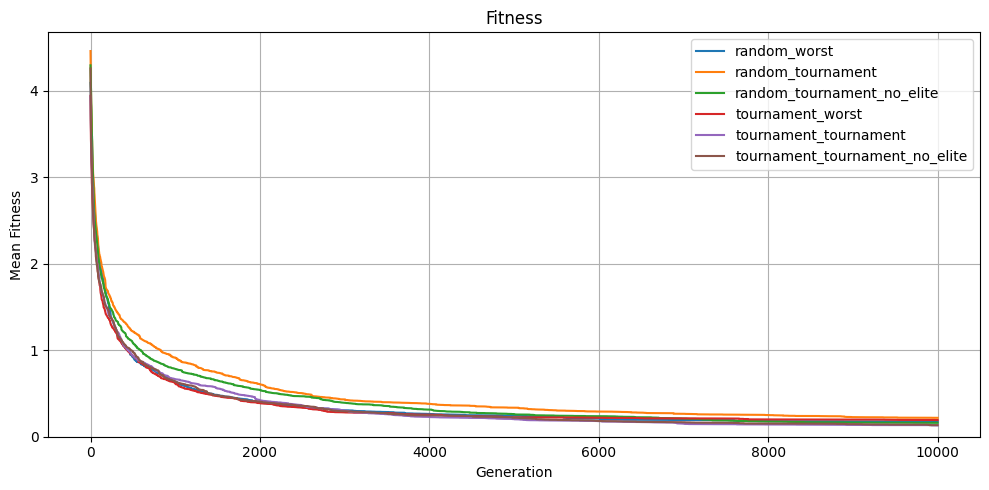

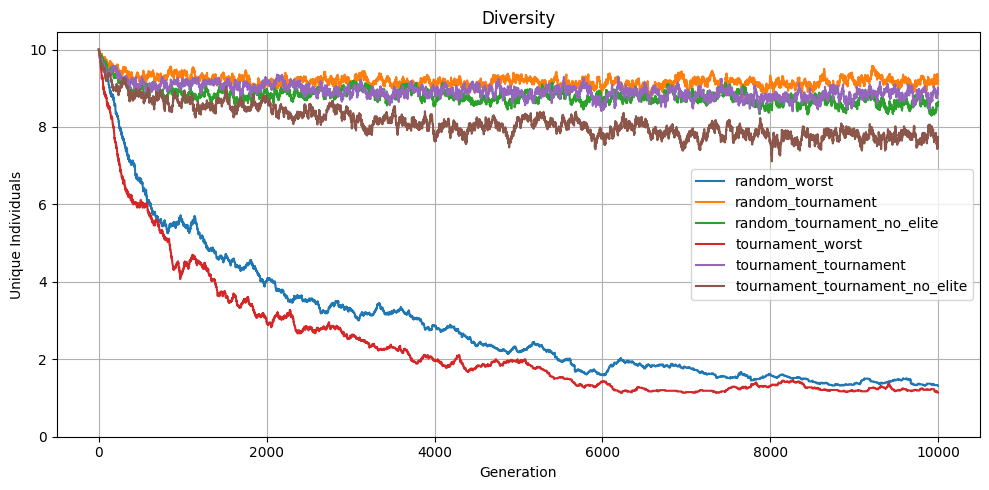

In [12]:
plot_metric(mean_j_p_per_strategy, "Pitch Error", "Mean Jaccard Pitch Error", save=True)
plot_metric(mean_j_i_per_strategy, "Instrument Error", "Mean Jaccard Instrument Error", save=True)
plot_metric(mean_j_ip_per_strategy, "Combined Error", "Mean Jaccard Combined Error", save=True)
plot_metric(mean_fitness_per_strategy, "Fitness", "Mean Fitness", save=True)
plot_metric(mean_diversity_per_strategy, "Diversity", "Unique Individuals", save=True)